# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Krishna Lund
**Student ID:** 023-24-0271
**Section:**  H
**GitHub:** https://github.com/Krishnalund/machine-learning-practical-work
**Kaggle:** https://www.kaggle.com/krishnalund18
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
 import pandas as pd
 import numpy as np
 import matplotlib.pyplot as plt
 import re
 from sklearn.model_selection import train_test_split
 from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
 from sklearn.naive_bayes import MultinomialNB
 from sklearn.linear_model import LogisticRegression
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [2]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam = pd.read_csv('spam.csv', encoding='iso-8859-1')
print(spam.shape)
print(spam.head())
print(spam.iloc[:,0].value_counts())
spam = spam[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})
print(spam.columns.tolist())
spam.head()

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
v1
ham     4825
spam     747
Name: count, dtype: int64
['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets = pd.read_csv('Tweets.csv')
print(tweets.shape)
print(tweets['airline_sentiment'].value_counts())

tweets = tweets[tweets['airline_sentiment'] != 'neutral'].reset_index(drop=True)
print(tweets.shape)

(14640, 15)
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
(11541, 15)


**Answer 2 (Task A — spam):**
_(The spam.csv dataset contains 5,572 SMS messages, each row representing one text message labeled as ham or spam. 
  The classes are imbalanced: 4,825 ham (86.6%) and 747 spam (13.4%).)_

**Answer 2 (Task B — sentiment):**
_(14,640 tweets originally, each row representing one tweet about a US airline labeled positive/negative/neutral. 
  After dropping the 3,099 neutral tweets, 11,541 rows remain: 9,178 negative (79.5%) and 2,363 positive (20.5%) — 
  a fairly imbalanced dataset skewed toward negative sentiment.)_

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [4]:
# Task 3 — clean text
spam['message_clean'] = spam['message'].str.lower()
spam['message_clean'] = spam['message_clean'].apply(lambda x: re.sub(r'[^a-z0-9\s]', '', x))

spam[['message', 'message_clean']].head()

,message,message_clean
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [5]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam['label_num'] = spam['label'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(
    spam['message_clean'], spam['label_num'],
    test_size=0.2, random_state=42, stratify=spam['label_num']
)
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary size:", len(vectorizer.get_feature_names_out()))
print("Train shape:", X_train_vec.shape)
print("Test shape:", X_test_vec.shape)

Vocabulary size: 8343
Train shape: (4457, 8343)
Test shape: (1115, 8343)


**Answer 4 (why fit on training data only):**
_(The vectorizer should be fitted only on the training data. If we fit it on the full dataset, the model can get information from the test data, 
  causing data leakage. By using fit_transform() on X_train and only transform() on X_test, the test data stays unseen,
  giving us a more honest measure of how well the model works on new data.)_

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy:  0.9516
Precision: 1.0000
Recall:    0.6376
F1-score:  0.7787


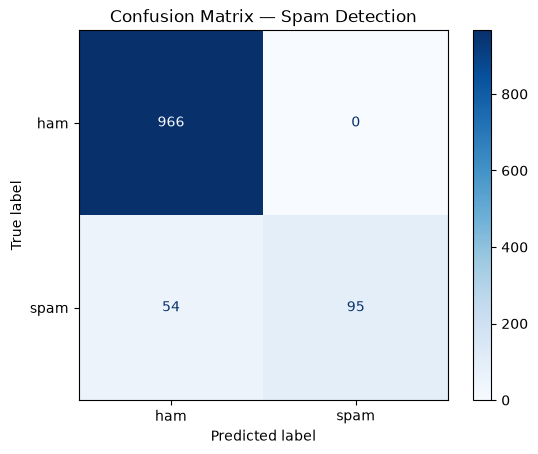

In [6]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

y_pred = nb_model.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Spam Detection")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9516 |
| Precision | 1.0000 |
| Recall | 0.6376 |
| F1-score | 0.7787 |

**Answer 6:**
_(A false positive means a real message is incorrectly classified as spam, while a false negative means a spam message is allowed through. 
  In this model, there are no false positives, but there are 54 false negatives. Therefore, the model is very careful when marking messages 
  as spam but misses some spam messages. If we tune the model further, we should focus on Recall to detect more spam messages.)_

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [7]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_

feature_names = vectorizer.get_feature_names_out()
log_prob_ham = nb_model.feature_log_prob_[0]  
log_prob_spam = nb_model.feature_log_prob_[1]  

log_prob_diff = log_prob_spam - log_prob_ham

top_spam_idx = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_idx = np.argsort(log_prob_diff)[:15]

top_spam_words = [(feature_names[i], log_prob_diff[i]) for i in top_spam_idx]
top_ham_words = [(feature_names[i], log_prob_diff[i]) for i in top_ham_idx]

print("Top 15 words associated with SPAM:")
for word, score in top_spam_words:
    print(f"  {word}: {score:.3f}")

print("\nTop 15 words associated with HAM:")
for word, score in top_ham_words:
    print(f"  {word}: {score:.3f}")

Top 15 words associated with SPAM:
  claim: 3.457
  prize: 3.236
  won: 3.114
  urgent: 2.785
  guaranteed: 2.776
  nokia: 2.740
  500: 2.735
  1000: 2.721
  tone: 2.684
  18: 2.660
  txt: 2.594
  16: 2.556
  awarded: 2.537
  service: 2.532
  150ppm: 2.522

Top 15 words associated with HAM:
  ill: -3.340
  my: -3.243
  ltgt: -3.157
  ok: -3.126
  later: -3.047
  lor: -2.984
  im: -2.912
  come: -2.876
  home: -2.851
  but: -2.843
  da: -2.833
  sorry: -2.763
  me: -2.722
  he: -2.594
  going: -2.568


**Answer 7:**
_(The top spam words made sense because words like “claim,” “prize,” “won,” “urgent,” and “guaranteed” are common in scam messages. Numbers like “500” and “1000” also make sense because spam often includes prize amounts. The ham words were more normal, such as “ok,” “sorry,” “home,” and “come.” I found it interesting that the model could clearly separate spam words from everyday conversation. Overall, the results showed that spam focuses more on rewards and urgency, while ham messages use normal conversational words.
)_

In [8]:
# Task 8 — test your own messages
my_messages = [
    "WINNER!! You have been selected to receive a $900 prize. Call now to claim!",   
    "Hey, are we still on for lunch tomorrow? Let me know!",                          
    "Congrats on the new job! You deserve it, call me later to celebrate",            
    "URGENT meeting moved to 3pm, please confirm asap",                              
    "u still up? txt me when free",                                                   
]
my_messages_clean = [re.sub(r'[^a-z0-9\s]', '', m.lower()) for m in my_messages]
my_messages_vec = vectorizer.transform(my_messages_clean)
predictions = nb_model.predict(my_messages_vec)
probabilities = nb_model.predict_proba(my_messages_vec)

for msg, pred, prob in zip(my_messages, predictions, probabilities):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f"Message: {msg}")
    print(f"  → Predicted: {label} (P(ham)={prob[0]:.3f}, P(spam)={prob[1]:.3f})\n")


Message: WINNER!! You have been selected to receive a $900 prize. Call now to claim!
  → Predicted: SPAM (P(ham)=0.108, P(spam)=0.892)

Message: Hey, are we still on for lunch tomorrow? Let me know!
  → Predicted: HAM (P(ham)=0.999, P(spam)=0.001)

Message: Congrats on the new job! You deserve it, call me later to celebrate
  → Predicted: HAM (P(ham)=0.983, P(spam)=0.017)

Message: URGENT meeting moved to 3pm, please confirm asap
  → Predicted: HAM (P(ham)=0.848, P(spam)=0.152)

Message: u still up? txt me when free
  → Predicted: HAM (P(ham)=0.977, P(spam)=0.023)



**Answer 8:**
_(The model correctly classified all five messages, even the tricky ones containing words commonly associated with spam. 
  For example, "URGENT meeting" received a higher spam probability because "urgent" is sometimes found in spam messages. 
  However, the other normal words in the message provided enough evidence for the model to classify it as ham. 
  This shows that Naive Bayes does not simply look for one spam word; it combines the evidence from many words when making its prediction.)_

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_(https://www.kaggle.com/code/krishnalund18/naive-bayes-spam-detection)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [13]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)       
    text = re.sub(r'@\w+', '', text)                  
    text = re.sub(r'#', '', text)                     
    text = re.sub(r'[^a-z0-9\s]', '', text)            
    text = re.sub(r'\s+', ' ', text).strip()           
    return text

tweets['text_clean'] = tweets['text'].apply(clean_tweet)
tweets['label_num'] = tweets['airline_sentiment'].map({'negative': 0, 'positive': 1})

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    tweets['text_clean'], tweets['label_num'],
    test_size=0.2, random_state=42, stratify=tweets['label_num']
)

vectorizer_b = TfidfVectorizer()
Xt_train_vec = vectorizer_b.fit_transform(Xt_train)
Xt_test_vec = vectorizer_b.transform(Xt_test)

print("Vocabulary size:", len(vectorizer_b.get_feature_names_out()))
print("Train shape:", Xt_train_vec.shape)
print("Test shape:", Xt_test_vec.shape)

tweets[['text', 'text_clean']].head()

Vocabulary size: 11135
Train shape: (9232, 11135)
Test shape: (2309, 11135)


,text,text_clean
0,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
1,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
2,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
3,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay 30 a flight for seats that...
4,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...


**Answer 12:**
_(URLs removed — Links do not usually tell us whether a tweet is positive or negative. Also, every link can be different, 
        so keeping them would add unnecessary noise.
  @mentions removed — Mentions mainly tell us who the tweet is directed to, not the sentiment. Keeping them could also make the model focus on the
        airline name instead of the actual words showing sentiment.
  Hashtag symbol removed, but the word kept — For example, hashneveragain becomes neveragain. Hashtag words can contain useful sentiment information, 
        so we keep the word but remove the hashtag symbol.)_

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy:  0.8285
Precision: 1.0000
Recall:    0.1628
F1-score:  0.2800


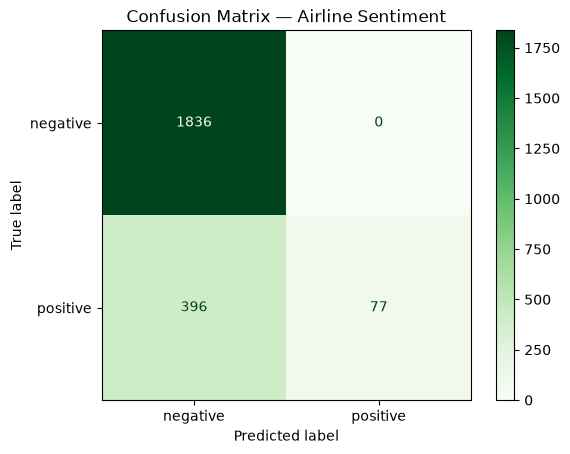

In [14]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
nb_model_b = MultinomialNB()
nb_model_b.fit(Xt_train_vec, yt_train)

yt_pred = nb_model_b.predict(Xt_test_vec)

acc_b = accuracy_score(yt_test, yt_pred)
prec_b = precision_score(yt_test, yt_pred)
rec_b = recall_score(yt_test, yt_pred)
f1_b = f1_score(yt_test, yt_pred)

print(f"Accuracy:  {acc_b:.4f}")
print(f"Precision: {prec_b:.4f}")
print(f"Recall:    {rec_b:.4f}")
print(f"F1-score:  {f1_b:.4f}")

cm_b = confusion_matrix(yt_test, yt_pred)
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['negative', 'positive'])
disp_b.plot(cmap='Greens')
plt.title("Confusion Matrix — Airline Sentiment")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8285 |
| Precision | 1.0000 |
| Recall | 0.1628 |
| F1-score | 0.2800 |

**Answer 14:**
_(Naive Bayes worked better for spam than sentiment. Spam messages often have clear words like “free,” “win,” and “call now,” so the model can easily detect them.
Sentiment is harder because tweets depend on context, such as “not good” or sarcasm. Naive Bayes treats each word separately, so it struggles to understand these meanings.
Also, because most tweets were negative, the model often predicted negative. This caused positive recall to drop from 0.64 to 0.16 and F1-score from 0.78 to 0.28.)_

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_(https://www.kaggle.com/code/krishnalund18/naive-bayes-sentiment-analysis)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9516 | 0.8285 |
| Precision | 1.0000 | 1.0000 |
| Recall | 0.6376 | 0.1628 |
| F1-score | 0.7787 | 0.2800 |

In [15]:
# Task 18 — train Logistic Regression on Task A's vectorized features

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train_vec, y_train)

y_pred_lr = logreg_model.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy:  {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall:    {rec_lr:.4f}")
print(f"F1-score:  {f1_lr:.4f}")

Accuracy:  0.9659
Precision: 0.9912
Recall:    0.7517
F1-score:  0.8550


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9516 | 0.9659 |
| Precision | 1.0000 | 0.9912 |
| Recall | 0.6376 | 0.7517 |
| F1-score | 0.7787 | 0.8550 |

**Answer 18 (which wins, and does it match expectations):**
_(Logistic Regression performs better. It has higher accuracy, recall, and F1-score. Its precision is only slightly lower than Naive Bayes.
Naive Bayes assumes that each word works independently. Logistic Regression learns how important each word is and uses those weights to make better decisions.
So, Logistic Regression is more flexible and can detect spam more effectively.)_

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
_(I learned that Naive Bayes worked better for spam detection because spam messages often contain common keywords. Its F1-score was 0.7787 for spam compared to 0.2800 for sentiment. I was surprised that some of the most predictive words were not always obvious spam words. Logistic Regression performed better than Naive Bayes, with an F1-score of 0.8550. This showed that Logistic Regression can make better use of word importance. One limitation I observed was that Naive Bayes treats words independently and struggles with context. For example, it can have difficulty understanding negation or phrases where words change each other’s meaning. Overall, I learned that Naive Bayes is simple and useful, but it has limitations when context is important.
)_

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/krishnalund18/naive-bayes-spam-detection
- Task B: https://www.kaggle.com/code/krishnalund18/naive-bayes-sentiment-analysis

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted